
<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## Make 2-level Hierarchical Clustered Spatial Data

### Michael Pyrcz, Professor, University of Texas at Austin 

##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### 2level_clustered.csv

A synthetic dataset with a course regular dataset and then infill drilling around the highest values.

* all sampling from a geostatistical unconditional simulation of porosity 

#### Load Functions

There are exampled below with these functions. You can go here to see a list of the available functions, https://git.io/fh4eX, other example workflows and source code. 

In [1]:
import geostatspy.GSLIB as GSLIB                              # GSLIB utilies, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python        

We will also need some standard packages. These should have been installed with Anaconda 3.

In [2]:
import numpy as np                                            # ndarrys for gridded data
import pandas as pd                                           # DataFrames for tabular data
import os                                                     # set working directory, run executables
import matplotlib.pyplot as plt                               # for plotting
from scipy import stats                                       # summary statistics
from ipywidgets import interactive                            # widgets and interactivity
from ipywidgets import widgets                            
from ipywidgets import Layout
from ipywidgets import Label
from ipywidgets import VBox, HBox
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)                                # set axes and grids in the background for all plots
from matplotlib.patches import Rectangle                      # drawing shapes on plots
from statsmodels.stats.weightstats import DescrStatsW
cmap = plt.cm.inferno

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs.  

#### Declare Functions

These functions read in the multiple realizations and produce local statistical summaries that we will cover below.  They will shortly be added to GeostatsPy.

In [12]:
def extract_porosity(x, y):                                   # function to extract porosity from grid
    ix = np.clip((x // xsiz).astype(int), 0, 99)
    iy = ny - np.clip((y // ysiz).astype(int), 0, 99) - 1 
    return por_sim[iy, ix]

#### Set the working directory

I always like to do this so I don't lose files and to simplify subsequent read and writes (avoid including the full address each time). 

In [8]:
#os.chdir("c:/PGE383")                                        # set the working directory

#### Reference Distribution

Make a reference distribution,

* Porosity distribution is Gaussian

* X and Y coordinates are outside the range of correlation from the AOI so have no impact locally

In [3]:
np.random.seed(42); n = 500                                   # null reference distribution dataset (out of AOI)

X = np.random.uniform(-200000, -100000, n); Y = np.random.uniform(-200000, -100000, n)
porosity = np.random.normal(loc=10.0, scale=2.0, size=n) # Gaussian distributed porosity

df_null = pd.DataFrame({"X": X,"Y": Y,"Porosity": porosity})  
df_null.head()

,X,Y,Porosity
0,-162545.988115,-130183.828598,10.355402
1,-104928.569359,-146390.363366,7.329311
2,-126800.605819,-169047.238371,10.760396
3,-140134.151580,-118620.498029,11.221171
4,-184398.135956,-131526.882745,11.119581


#### Simulated Truth Model

Unconditional simulation with,

* distribution from the reference distribution above

* long, anisotropic variogram range


 Data for SGSIM: Number of acceptable data     = 500
                 Number trimmed                = 0
                 Weighted Average              = 10.2337
                 Weighted Variance             = 3.8651
                 Weighted Transformed Average  = 0.0
                 Weighted Transformed Variance = 0.9974
Setting up rotation matrices for variogram and search
Working on realization number 0
   currently on node 0
   currently on node 1000
   currently on node 2000
   currently on node 3000
   currently on node 4000
   currently on node 5000
   currently on node 6000
   currently on node 7000
   currently on node 8000
   currently on node 9000
Reassigning data to nodes

 Realization 0: number   = 10000
                                   mean     = -0.1043 (close to 0.0?)
                                   variance = 0.8515 (close to gammabar(V,V)? approx. 1.0)


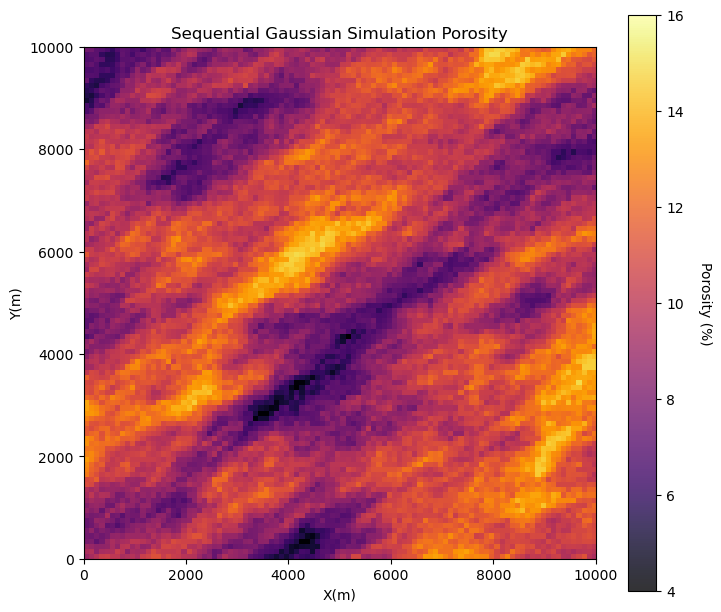

In [10]:
nx = 100; xmn = 50.0; xsiz = 100.0;                           # truth model grid parameters
ny = 100; ymn = 50.0; ysiz = 100.0;

xmin = xmn - xsiz*0.5; xmax = xmin + nx*xsiz; ymin = ymn - ysiz*0.5; ymax = ymin + ny*ysiz

vrel_nugget = 0.0; sill = 1.0; vazi = 60.0; vrange_maj = 5000.0; vrange_min = 2000.0
tmin = -9999.0; tmax = 9999.0; pormin = 4.0; pormax = 16.0
por_vario = GSLIB.make_variogram(nug=vrel_nugget*sill,nst=1,it1=1,cc1=(1.0-vrel_nugget)*sill,
         azi1=vazi,hmaj1=vrange_maj,hmin1=vrange_min)         # porosity variogram

ktype = 0                                                     # kriging type, 0 - simple, 1 - ordinary
radius = 5000                                                 # search radius for neighbouring data
nxdis = 1; nydis = 1                                          # number of grid discretizations for block kriging
ndmin = 0; ndmax = 10                                         # minimum and maximum data for an estimate

por_sim = geostats.sgsim(df_null,'X','Y','Porosity',wcol=-1,scol=-1,tmin=tmin,tmax=tmax,itrans=1,ismooth=0,dftrans=0,tcol=0,
            twtcol=0,zmin=pormin,zmax=pormax,ltail=1,ltpar=0.0,utail=1,utpar=0.3,nsim=1,
            nx=nx,xmn=xmn,xsiz=xsiz,ny=ny,ymn=ymn,ysiz=ysiz,seed=73073,
            ndmin=0,ndmax=20,nodmax=20,mults=0,nmult=2,noct=-1,
            ktype=0,colocorr=0.0,sec_map=0,vario=por_vario)[0]

plt.subplot(111)                                              # pixelplot and location map
GSLIB.pixelplt_st(por_sim,xmin,xmax,ymin,ymax,xsiz,pormin,pormax,'Sequential Gaussian Simulation Porosity','X(m)','Y(m)','Porosity (%)',cmap)
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.2, wspace=0.2, hspace=0.2); plt.show()

#### Sample from the Truth Model

Course grid with course spacing, then random infill near top values

        X       Y   Level   Porosity
0  1000.0  1000.0  Coarse   8.105355
1  2000.0  1000.0  Coarse   8.004545
2  3000.0  1000.0  Coarse  11.379058
3  4000.0  1000.0  Coarse   8.753054
4  5000.0  1000.0  Coarse   8.020658

Total samples: 131


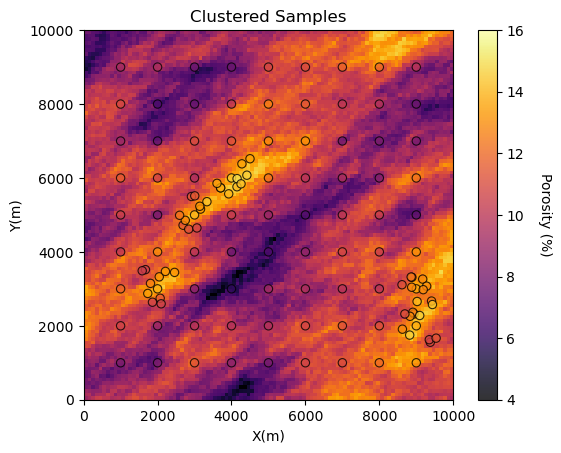

In [13]:
np.random.seed(42)

# -------------------------------------------------
# 1. Regular Grid (spacing-controlled)
# -------------------------------------------------
course_spacing = 1000
n_grid = 9

# Start half a spacing inside boundary so grid is centered in cells
start = course_spacing
end = start + course_spacing * (n_grid - 1)

x_vals = np.arange(start, end + course_spacing, course_spacing)
y_vals = np.arange(start, end + course_spacing, course_spacing)

xx, yy = np.meshgrid(x_vals, y_vals)
coarse_points = np.column_stack([xx.ravel(), yy.ravel()])

df_coarse = pd.DataFrame(coarse_points, columns=["X", "Y"])
df_coarse["Level"] = "Coarse"

df_coarse["Porosity"] = extract_porosity(df_coarse["X"], df_coarse["Y"])

# -------------------------------------------------
# 2. Find top n_top coarse samples (from 9x9 grid)
# -------------------------------------------------
n_top = 5   # << control number of targets here

# Sort coarse dataframe by porosity (descending)
df_top = df_coarse.sort_values(by="Porosity", ascending=False).head(n_top)

# Convert their coordinates to grid indices
ix_top = np.clip((df_top["X"] // xsiz).astype(int), 0, 99)
iy_top = np.clip((df_top["Y"] // ysiz).astype(int), 0, 99)

top_indices = np.column_stack([iy_top, ix_top])

# -------------------------------------------------
# 3. Random infill within 500x500 box
# -------------------------------------------------
n_infill = 10          # << control number here
box_half = 500         # 500m box

infill_points = []

for iy_top, ix_top in top_indices:

    # center of high-value cell
    x_center = ix_top * xsiz + xsiz / 2
    y_center = iy_top * ysiz + ysiz / 2

    # random sampling inside box
    x_rand = np.random.uniform(x_center - box_half,
                               x_center + box_half,
                               n_infill)

    y_rand = np.random.uniform(y_center - box_half,
                               y_center + box_half,
                               n_infill)

    # clip to global domain
    x_rand = np.clip(x_rand, xmin, xmax)
    y_rand = np.clip(y_rand, ymin, ymax)

    for x_i, y_i in zip(x_rand, y_rand):
        infill_points.append([x_i, y_i])

df_infill = pd.DataFrame(infill_points, columns=["X", "Y"])
df_infill["Level"] = "Infill"
df_infill["Porosity"] = extract_porosity(df_infill["X"], df_infill["Y"])

# -------------------------------------------------
# 4. Final hierarchical dataset
# -------------------------------------------------
df_final = pd.concat([df_coarse, df_infill], ignore_index=True)

print(df_final.head())
print("\nTotal samples:", len(df_final))

GSLIB.locpix_st(por_sim,xmin,xmax,ymin,ymax,xsiz,pormin,pormax,df_final,'X','Y','Porosity','Clustered Samples','X(m)','Y(m)','Porosity (%)',cmap)

#### Save the Dataframe

In [14]:
df_final.to_csv("2level_cluster.csv", sep=",", index=False)

#### Comments

This was a workflow to make a hierarchical 2-level clustered spatial dataset. This will be useful for demonstrating the imapct of clustered (biased) sampling and for demonstrating geostatistical declustering methods. 

I hope this was helpful,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Associate Professor The Hildebrand Department of Petroleum and Geosystems Engineering, Bureau of Economic Geology, The Jackson School of Geosciences, The University of Texas at Austin

#### More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)
